# Act 1.1 Image DIY

In this activity, we just make synthetic images using matplotlib! 

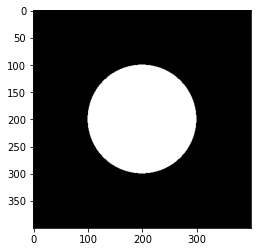

In [1]:
# here we just create a synthetic image of a circle

import numpy as np 
import matplotlib.pyplot as plt 
from scipy import signal
import matplotlib.image as mpimg
from matplotlib.patches import RegularPolygon
from PIL import Image
import math 

N = 400

x = np.linspace(-1, 1, num=N)
y = x
X, Y = np.meshgrid(x,y)


R = np.sqrt(X**2 + Y**2)
A = np.zeros(np.shape(R))

A[np.where(R<0.5)] = 1
plt.imshow(A, cmap = 'gray')

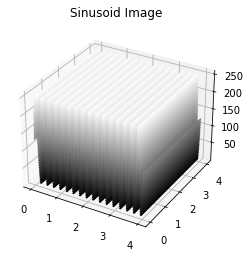

In [2]:
# here, we make a sinusoid

def f(x, y):
    return 127.5*np.sin(8*np.pi*x)+127.5   # sine wave construction (4 cycles/cm and amplitude of 0-255)


x = np.linspace (0 , 4, num=N)
y = x

X, Y = np.meshgrid(x, y)
Z = f(X, Y)


fig = plt.figure()
ax = plt.axes(projection='3d')
plot_sine = ax.contour3D(X, Y, Z, 50, cmap='gray')
ax.set_title('Sinusoid Image')

# Source: https://jakevdp.github.io/PythonDataScienceHandbook/04.12-three-dimensional-plotting.html


# Now we save the figure. We made a 3d figure plot so it's not stored as an array 
# so we use plt.savefig instead of plt.imread
plt.savefig('GraySine.jpg')
plt.savefig('GraySine.png')
plt.savefig('GraySine.tiff')
# bmp is not supported 

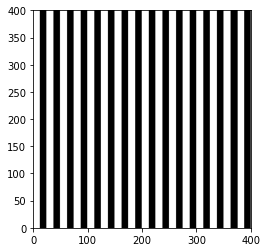

In [3]:
# here, we simulate gratings

from scipy import signal  # we make a square wave

y = np.linspace(0, 4, 500, endpoint=False)

x = signal.square(2 * np.pi * 5 * y) + 1

X, Y = np.meshgrid(x, y)
plt.xlim(0,400)
plt.ylim(0,400)
plt.imshow(X, cmap='gray')

In [4]:
# We save the gratings image

rgb = X
rgbim = rgb*255
img = rgbim.astype(np.uint8)
# plt.imshow(img)
plt.imsave("Gratings.jpg",img)
plt.imsave("Gratings.bmp",img)
plt.imsave("Gratings.png",img)
plt.imsave("Gratings.tiff",img)

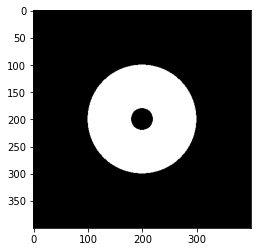

In [5]:
x = np.linspace(-1, 1, num=N)
y = x
X, Y = np.meshgrid(x,y)


R = np.sqrt(X**2 + Y**2)
A = np.zeros(np.shape(R))

A[np.where(R<0.5)] = 1
A[np.where(R<0.1)] = 0
plt.imshow(A, cmap = 'gray')

In [6]:
# We save the hubble primary mirror image

rgb = A
rgbim = rgb*255
img = rgbim.astype(np.uint8)
# plt.imshow(img)
plt.imsave("HubblePrimary.jpg",img)
plt.imsave("HubblePrimary.bmp",img)
plt.imsave("HubblePrimary.png",img)
plt.imsave("HubblePrimary.tiff",img)

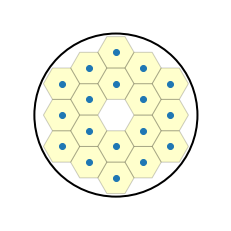

In [7]:
# Source: https://stackoverflow.com/questions/46525981/how-to-plot-x-y-z-coordinates-in-the-shape-of-a-hexagonal-grid
# Source 2 - my classmate Niño Ramones helped me calculate the centers :>


coord = [[0, 1, -1], [-1, 1, 0], [-1, 0, 1], [0, -1, 1], [1, -1, 0], [1, 0, -1], 
         [-1, 4, 1], [0, 5, 1], [1, 3, 0], [2, 2, 0], [2, 0, 0], [2, -2, 0], [1, -3, 0],
          [0, -4, 0], [-1, -3, 0], [-2, -2, 0], [-2, 0, 0], [-2, 2, 0]]
colors = [["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],
          ["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],["Yellow"],['Yellow'],['Yellow']]


# Horizontal cartesian coords
hcoord = [c[0] for c in coord]

# Vertical cartersian coords
vcoord = [2. * np.sin(np.radians(60)) * (c[1] - c[2]) /3. for c in coord]

fig, ax = plt.subplots(1)
ax.set_aspect('equal')

# Add some coloured hexagons
for x, y, c in zip(hcoord, vcoord, colors):
    color = c[0].lower()  # matplotlib understands lower case words for colours
    hex = RegularPolygon((x, y), numVertices=6, radius=2. / 3., 
                         orientation=np.radians(30), 
                         facecolor=color, alpha=0.2, edgecolor='k')
    ax.add_patch(hex)

# Also add scatter points in hexagon centres
ax.scatter(hcoord, vcoord)

circ = plt.Circle((0 ,0), 3 , fill=False, lw=2, color="black")
ax.set_aspect(1)
ax.add_artist(circ)

plt.xlim(-4,4)
plt.ylim(-4,4)
plt.axis('off')
plt.savefig('Hex.jpg')
plt.savefig('Hex.png')
plt.savefig('Hex.tiff')


plt.show()

# Act 1.2 Color Image

In this actiivity, we study how colors combine in a computer screen through constructive interference. 

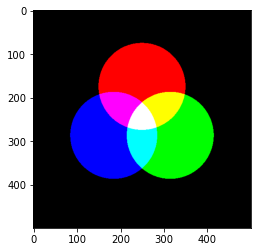

In [8]:
N = 500    # 500 pixels
x = np.linspace(-10,10,num = N) 
y = x

X,Y = np.meshgrid(x,y)

Rd = np.zeros((N,N))
Gn = np.zeros((N,N))
Bl = np.zeros((N,N))

#draw colored circles
Rt, Rc, deg = 3, 4, 30

xt = Rt*np.cos(deg*np.pi/180)  # args inside cos and sin just converts deg to rad
yt = Rt*np.sin(deg*np.pi/180)  # xt and yt are 

R = np.sqrt((X)**2 + (Y+Rt)**2)
Rd[np.where(R<Rc)]=1.0
R = np.sqrt((X-xt)**2 + (Y-yt)**2)
Gn[np.where(R<Rc)]=1.0
R = np.sqrt((X+xt)**2 + (Y-yt)**2)
Bl[np.where(R<Rc)]=1.0


I = np.zeros((N,N,3))
I[...,0] = Rd
I[...,1] = Gn
I[...,2] = Bl
fig = plt.figure()
plt.imshow(I)

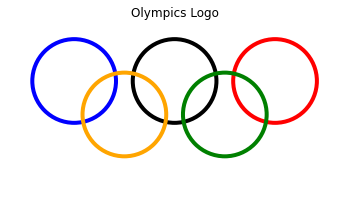

In [9]:
# to draw circles in matplotlib: c
# documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Circle.html




radius = 0.5    # radius and thickness of circles
thickness = 4

fig, ax = plt.subplots()
blu = plt.Circle(( -1.2 , 0.3 ), radius , fill=False, lw=thickness, color="blue")
bla = plt.Circle(( 0 , 0.3 ), radius , fill=False, lw=thickness, color="black")
red = plt.Circle(( 1.2 , 0.3 ), radius , fill=False, lw=thickness, color="red")
yel = plt.Circle(( -0.6 , -0.1 ), radius , fill=False, lw=thickness, color="orange")
grn = plt.Circle(( 0.6 , -0.1 ), radius , fill=False, lw=thickness, color="green")


ax.set_aspect(1)
ax.add_artist(blu)
ax.add_artist(bla)
ax.add_artist(red)
ax.add_artist(yel)
ax.add_artist(grn)

plt.xlim(-2, 2)
plt.ylim(-1, 1)
plt.axis('off')    # you can turn on the ticks to mess around with the circles' positions

plt.title('Olympics Logo')

plt.savefig('GraySine.jpg')
plt.savefig('GraySine.png')
plt.savefig('GraySine.tiff')


# numpy_fig = mplfig_to_npimage(fig)  # convert it to a numpy array

# # now we save

# rgb = numpy_fig
# rgbim = rgb*255
# img = rgbim.astype(np.uint8)
# # plt.imshow(img)
# plt.imsave("Olympics.jpg",img)
# plt.imsave("Olympics.bmp",img)
# plt.imsave("Olympics.png",img)
# plt.imsave("Olympics.tiff",img)

### JPEG (Joint Photographic Experts Group)
a file format that is based on lossy compression in order to produced images that take up little memory.

### PNG (Portable Network Graphics)
a file format that uses lossless compression in order to preserve image quality at the cost of a larger file size. 

### BMP (Bitmap)
generally used by older graphical UIs. It maps a domain (like a set of numbers) into bits without a natural compression, and has widespread support in Windows applications. 

### TIFF (Tagged Image File Format
has widespread use in the industry due to its flexibility. It contains both image and data (applied compression, size, etc..) and supports both lossy and lossless compression. Ideal for high quality images. 


Source: https://creativemarket.com/blog/difference-between-jpg-png-bmp-tiff-images#:~:text=While%20both%20PNG%20and%20JPG,sheer%20quality%20of%20your%20prints.


# Act 1.3 Altering the Input-Output Curve

You can find the raw and GIMP manipulated photo in the image folder. The image is of Freeside, the slums that surround the city of New Vegas ruled by the autocrat - Mr. House. You can read about it here:

https://fallout.fandom.com/wiki/Freeside

# Act 1.4 Histogram Backprojection on Grayscale Image

I uncommented the lines that plots each figure in the separate notebooks so it's not cluttered. If you want to skip to the figures, see the mini-section after this just before Act 1.5. You can also just skip to the images in the same file directory.

In [10]:
# First we save the image 
img = mpimg.imread('Freeside.png')
# imgplot = plt.imshow(img)
# plt.title('Original Image (3D Array)')
# plt.axis('off')
# plt.show()

In [11]:
# The first part of this activity is to convert a colored image into grayscale
# Source: https://stackoverflow.com/questions/12201577/how-can-i-convert-an-rgb-image-into-grayscale-in-python
# We can use the ITU-R 601-2 luma transform to calculate rgb to grayscale, or we can just call the Pillow module
# which basically does the same thing. In this case, we do the latter 

img = Image.open('Freeside.png')  # from PIL (Pillow) module 

GS = np.array(img.convert('L'))

# plt.title('Grayscale Image (0-255)')
# plt.axis('off')
# plt.imshow(GS, cmap = 'gray')


In [12]:
# Now we calculate the histogram of the greyscale image (if we normalize w/ density=True, it's the PDF!)

flat_GS = GS.flatten()
PDF_hist, PDF_edges = np.histogram(GS, bins = 256, range = (0,256), density=True) # PDF_hist is redundant lmao

# Now we plot a histogram. If we use plt.plot() it's just a line tho we can still see the trend
# plt.hist(flat_GS, 256 ,[0,256])  
# plt.title('Grayscale Histogram (Probability Density Function - PDF)')

# plt.show()

In [13]:
CDF = np.cumsum(PDF_hist)  # we calculate the CDF

# plt.plot(CDF)
# plt.title('Cumulative Distribution Function (CDF) of Grayscale Photo')  # show the CDF

In [14]:
# Now we make the desired CDF, which is a linear line. We start with creating a uniform PDF. 

num_bins = 256
uniform_data = np.array([])

uniform_data = np.array([range(0, 256)]) # one data point for each bin
    
uniform_PDF, uniform_binedge = np.histogram(uniform_data, bins = num_bins, range = (0,num_bins), density = True)
# plt.plot(uniform_PDF)
# plt.title('A Uniform Probability Density Function')

uniform_CDF = np.cumsum(uniform_PDF)

In [15]:
# plt.plot(uniform_CDF)             # this is the desired CDF
# plt.title('Target CDF (Linear)') # this is the CDF we want according to the problem, THIS IS ARBITRARY

In [16]:
# Recall that .flatten() converted the 2D greyscale image matrix into a 1D array
# of its pixel values from 0-255. What we do now is to look at the old CDF. Take a pixel value from flat_GS.
# This is the x-axis, now take the corresponding y-value. Go now to the target CDF. Take your y-value, then
# find the corresponding x-value. This x-value is your new and corrected pixel value to replace flat_GS
# This is BACKPROJECTION. 

# SOURCE : JULIAN MAYPA, classmate and Sir Kenneth, Rene 

x = np.arange(0, 256)

new_flatGS = np.interp(CDF[flat_GS], x, uniform_CDF) # CDF[flat_GS]; flat_GS has vals 0-255 which we use as indices 
new_GS = np.reshape(new_flatGS, np.shape(GS))  # not uint8, this is 0-1

# plt.imshow(new_GS, cmap='gray')
# plt.title('Corrected Grayscale Image (Linear CDF)')
# plt.axis('off')

plt.imsave('Freeside Linear.png', new_GS, cmap='gray')

# NOTE

The weird discolorations on the sky, and the weird "wires" on the Freeside sign are not image artifacts (see the image folder). This photo was a screenshot from Fallout: New Vegas, a game released more than a decade ago. These weird artifacts are due to the way developers handled the graphics during night time. You can see that this is not my doing in Act 1.3. since GIMP also detects these weird regions. However, this is not entirely the fault of Obsidian Studios. I initially saved the image as a JPEG, and then converted it to PNG using Gimp. Hence, this activity served a double purpose for me - that is it taught me firsthand the effects of lossy compression. 

In [17]:
# We calculate the PDF of the new backprojected photo 

PDF_hist_new, PDF_edges_new = np.histogram(new_GS, bins = 256 ,density=True) 
# plt.title('Grayscale Histogram of Corrected Image')
# plt.plot(PDF_hist_new)


In [18]:
CDF_new = np.cumsum(PDF_hist_new)  # we calculate the CDF

# plt.plot(CDF_new) 
# plt.title('Cumulative Distribution Function of Corrected Image')  # show the CDF

## Act 1.4. Backprojection Figures 

Text(0.5, 0.98, 'Stock and Backprojected Photos')

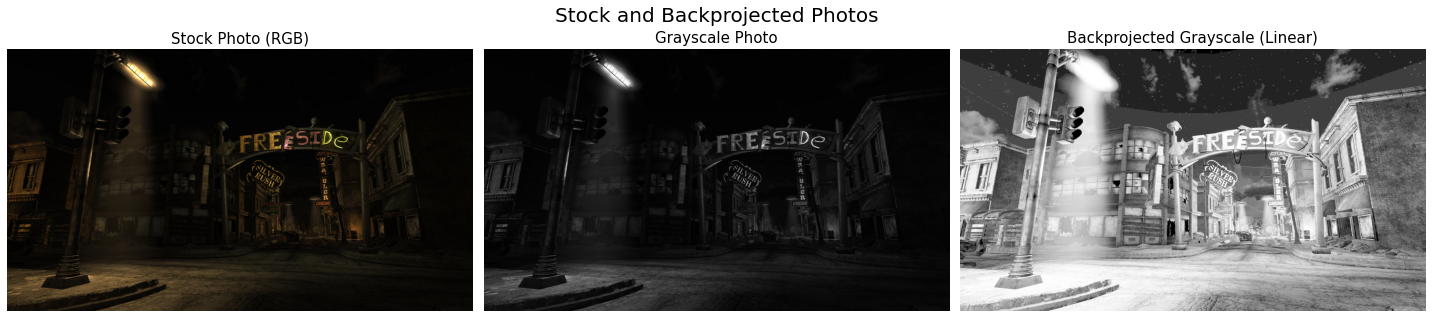

In [19]:
fig, ax = plt.subplots(1, 3)

ax[0].imshow(img)                 # this is the stock photo 
ax[1].imshow(GS, cmap='gray')     # this is the uncorrected GS photo
ax[2].imshow(new_GS, cmap='gray') # this is the corrected GS photo (Linear Correction),
                                  # ctrl + F mo nalang future self

fig.set_size_inches(20, 5, forward=True)

ax[0].set_title('Stock Photo (RGB)', fontsize='15')
ax[1].set_title('Grayscale Photo', fontsize='15')
ax[2].set_title('Backprojected Grayscale (Linear)', fontsize='15')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

fig.tight_layout()
fig.suptitle('Stock and Backprojected Photos', fontsize='20')

Text(0.5, 0.98, 'Point Density and Cumulative Density Functions')

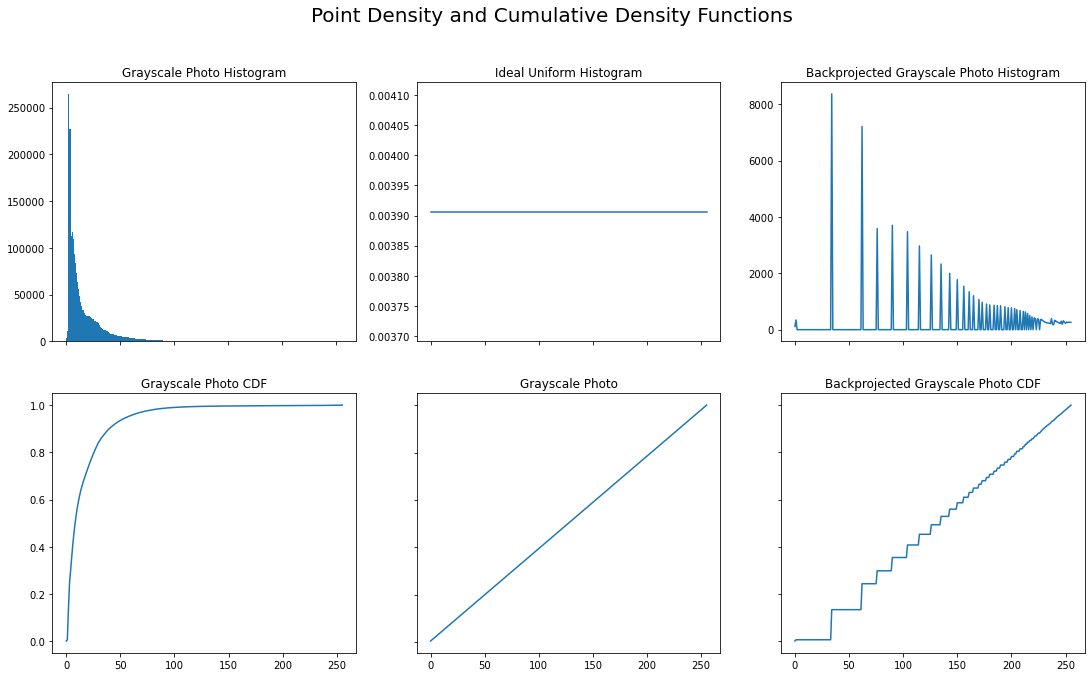

In [20]:
fig, ax = plt.subplots(2, 3)

ax[0,0].hist(flat_GS, 256 ,[0,256])  # this is the histogram of the GS photo 
ax[0,1].plot(uniform_PDF)            # this is our desired PDF in a perfect world 
ax[0,2].plot(PDF_hist_new)           # this is the histogram of the backprojected GS photo 

ax[1,0].plot(CDF)                    # this is the CDF of the GS photo 
ax[1,1].plot(uniform_CDF)            # this is our Linear ideal CDF 
ax[1,2].plot(CDF_new/65700)          # this is the CDF of the backprojected GS photo 
# I added the 65,700 because I can't find how to normalize it lmao if you catch this sir im sorry
# pang-graph lang naman para maganda itsura kapag lahat normalized 

ax[0,0].set_title('Grayscale Photo Histogram')
ax[0,1].set_title('Ideal Uniform Histogram')
ax[0,2].set_title('Backprojected Grayscale Photo Histogram')
ax[1,0].set_title('Grayscale Photo CDF')
ax[1,1].set_title('Grayscale Photo')
ax[1,2].set_title('Backprojected Grayscale Photo CDF')

ax[0,0].set_xticklabels([])
ax[0,1].set_xticklabels([])
ax[0,2].set_xticklabels([])

ax[1,1].set_yticklabels([])
ax[1,2].set_yticklabels([])

fig.set_size_inches(18.5, 10.5, forward=True)

fig.suptitle('Point Density and Cumulative Density Functions', fontsize='20')

# Act 1.5 Contrast Enhancement

In [21]:
# We use an image from: https://github.com/ml-workgroup/covid-19-image-repository/tree/master/png
# "The image data in this repository has been collected from the Institute for Diagnostic and
# Interventional Radiology, Hannover Medical School, Hannover, Germany and are licensed under 
# the Creative Commons Attribution 3.0 Unported."

img = Image.open('Covid Patient.png')  # from PIL (Pillow) module 

covid = np.array(img.convert('L'))
# plt.axis('off')
# plt.imshow(covid, cmap = 'gray')

In [22]:
# Define a function to find the nearest value in a numpy array given an input from a user
# Source: https://stackoverflow.com/questions/2566412/find-nearest-value-in-numpy-array

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx] 


def contrast_stretch(GS):   # input is a uint8 grayscale image array
    if GS.min() == 0 or GS.max() == 255: 
        hist, edge = np.histogram(GS, bins = 256, range = (0,256), density=True)
        CDF = np.cumsum(hist) 
        min_CDF = find_nearest(CDF, value = 0.1) # 10th percentile yval of CDF
        max_CDF = find_nearest(CDF, value = 0.9) # 90th percentile yval of CDF
        new_min = np.where(CDF == min_CDF)[0] # new min pixel val, [0] is there cuz np.where spits out two outputs
        new_max = np.where(CDF == max_CDF)[0] # new max pixel val
#         print(new_min, new_max)    # uncomment if you want to see the new min and max pixel vals
        GS_stretch = (GS - new_min / (new_max - new_min))        
    else: 
        GS_stretch = (GS - GS.min()) / (GS.max() - GS.min())
        
    return GS_stretch

covid_stretched = contrast_stretch(covid)
# plt.axis('off')
# plt.imshow(covid_stretched, cmap = 'gray')
plt.imsave('Covid Patient Contrast Stretch.png', covid_stretched, cmap='gray')

Text(0.5, 0.98, 'Contrast Stretching')

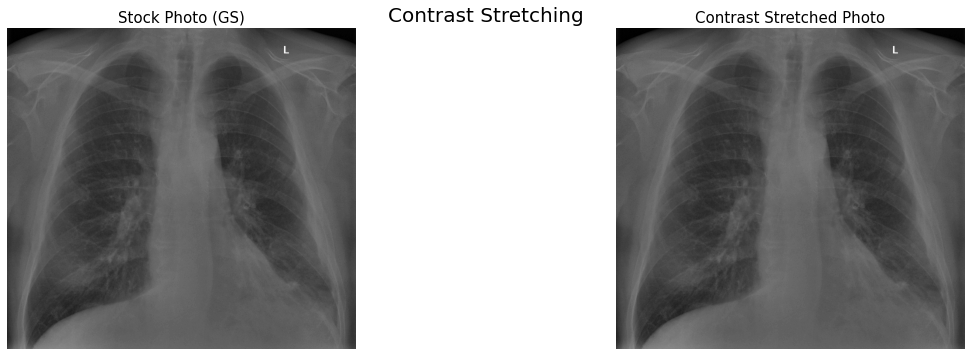

In [23]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(covid, cmap = 'gray')
ax[1].imshow(covid_stretched, cmap = 'gray')

fig.set_size_inches(20, 5, forward=True)

ax[0].set_title('Stock Photo (GS)', fontsize='15')
ax[1].set_title('Contrast Stretched Photo', fontsize='15')

ax[0].axis('off')
ax[1].axis('off')

fig.tight_layout()
fig.suptitle('Contrast Stretching', fontsize='20')

If you can't see the difference in this jupyter notebook, go to the images folder. The difference is much more pronounced there. 

# Restoring Faded Photographs


In [24]:
# faded_img = np.array(Image.open('MVM_pose2.png'))

# np.shape(faded_img)

(1080, 1920, 4)

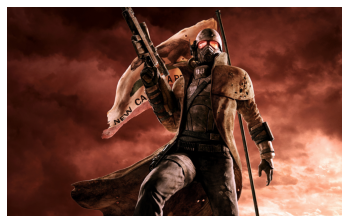

In [28]:
# Here we do RGB contrast stretching 

faded_img = np.array(Image.open('NCR Ranger.png'))  # from PIL (Pillow) module 
                                                    # has shape (LEN, WID, 3)

def RGB_contrast_stretch(faded_img):  # arg is image 3D numpy array
    rd_channel = faded_img[:,:,0]
    gr_channel = faded_img[:,:,1]
    bl_channel = faded_img[:,:,2]
    
    stretched_rd = contrast_stretch(rd_channel)
    stretched_gr = contrast_stretch(gr_channel)
    stretched_bl = contrast_stretch(bl_channel)
    
    # https://stackoverflow.com/questions/10443295/combine-3-separate-numpy-arrays-to-an-rgb-image-in-python
    restored_img = (np.dstack((stretched_rd,stretched_gr,stretched_bl))).astype(np.uint8)
    return restored_img

restored_img_contstretch = RGB_contrast_stretch(faded_img)

plt.axis('off')
plt.imshow(restored_img_contstretch)
plt.imsave('RGB Contrast Stretch test.png', restored_img_contstretch)
    
# np.shape(faded_img[:,:,0])
# plt.imshow(faded_img[:,:,2],cmap='gray')
    


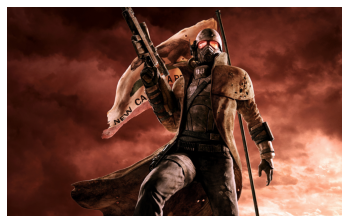

In [29]:
# Now we do the Gray World Algorithm 

def Gray_World(faded_img):
    rd_channel = faded_img[:,:,0]
    gr_channel = faded_img[:,:,1]
    bl_channel = faded_img[:,:,2]
    
    rd_ave = np.average(rd_channel)
    bl_ave = np.average(bl_channel)
    gr_ave = np.average(gr_channel)
    
    rd_whitebalanced = rd_channel / rd_ave
    bl_whitebalanced = bl_channel / bl_ave
    gr_whitebalanced = gr_channel / gr_ave
    
    restored_img = (np.dstack((stretched_rd,stretched_gr,stretched_bl))).astype(np.uint8)
    return restored_img

restored_img_grworld = RGB_contrast_stretch(faded_img)

plt.axis('off')
plt.imshow(restored_img_grworld)
plt.imsave('Gray World Algo test.png', restored_img_grworld)
    
    



In [27]:
# why in god's green earth are the images being black when the contrast of the image is low. 
# When the contrast is in the mid range it works just fine, you can see that the algo works and 
# but when i turn down the contrast in GIMP it just becomes black so imma read Griffiths instead
# im so done with this bye. AND ALSO why does the xray images here in jupyter look like they are 
# the same image like come on it works fine when you view it in a proper image software thingy you
# can see the improvement in contrast very much grrrrr skill issue smh bye again 